Machine Learning Workflow
1. Preprocessing + EDA + Feature Selection → Clean, understand, and select useful features from the dataset.
2. Extract Input and Output Columns → Separate input features (X) and target/output (y).
3. Scale the Values → Bring numerical features to a similar scale.
4. Train-Test Split → Divide the data into training and testing sets.
5. Train the Model → Train the ML algorithm using the training data.
6. Evaluate / Select the Model → Measure performance and choose the best model.
7. Deploy the Model → Make the trained model available for real-world predictions.

In [1]:
import numpy as np
import pandas as pd

In [17]:
df = pd.read_csv('../Dataset/placement.csv')

In [6]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
df.shape

(100, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [19]:
df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]

In [11]:
df

,iq,placement
0,123.0,1
1,106.0,0
2,121.0,0
3,132.0,1
4,142.0,0
...,...,...
95,200.0,0
96,42.0,0
97,182.0,1
98,103.0,1


In [13]:
import matplotlib.pyplot as plt


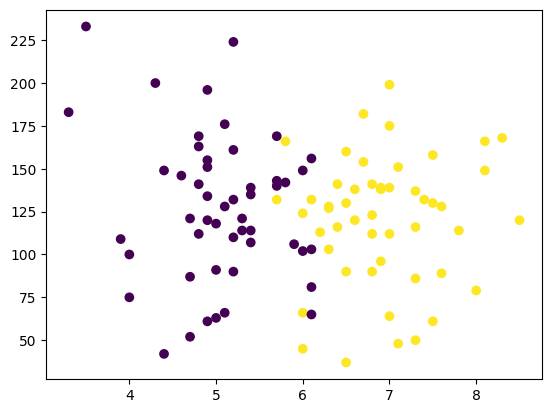

In [20]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [21]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [22]:

X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:

y.shape

(100,)

In [24]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [27]:
X_train

,cgpa,iq
71,6.1,132.0
10,6.0,45.0
94,4.7,52.0
2,5.3,121.0
33,6.0,149.0
...,...,...
63,6.3,128.0
83,7.5,130.0
64,7.0,64.0
69,8.5,120.0


In [28]:
y_train

71    1
10    1
94    0
2     0
33    0
     ..
63    1
83    1
64    1
69    1
61    1
Name: placement, Length: 90, dtype: int64

In [29]:
X_test

,cgpa,iq
1,5.9,106.0
77,7.3,50.0
49,5.4,135.0
76,4.9,155.0
7,5.0,63.0
3,7.4,132.0
6,5.7,143.0
43,6.8,141.0
57,6.5,130.0
78,6.1,81.0


In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
X_train = scaler.fit_transform(X_train)

In [33]:
X_train

array([[ 0.10392416,  0.18231543],
       [ 0.01811522, -1.98718276],
       [-1.09740102, -1.81262544],
       [-0.58254737, -0.09198894],
       [ 0.01811522,  0.60624036],
       [ 0.44715993, -2.18667685],
       [ 0.87620464, -0.31641979],
       [-2.29872621,  1.45409023],
       [-0.2393116 ,  1.10497558],
       [ 0.44715993,  0.88054473],
       [-1.01159208,  0.95535501],
       [-0.92578314,  0.65611388],
       [ 0.87620464,  1.8530784 ],
       [-0.15350266,  0.43168304],
       [ 0.61877781,  1.42915347],
       [ 1.820103  ,  1.0301653 ],
       [ 0.10392416,  0.78079769],
       [ 0.53296887, -0.1169257 ],
       [ 0.96201358, -1.91237248],
       [-0.75416526,  0.08256839],
       [-0.66835631,  2.47649743],
       [-0.58254737, -0.26654627],
       [-1.01159208, -0.31641979],
       [ 0.96201358,  0.65611388],
       [ 0.36135099, -0.21667274],
       [ 0.10392416, -0.54085063],
       [-0.8399742 , -0.84009176],
       [-0.75416526,  1.27953291],
       [ 0.10392416,

In [34]:
X_test = scaler.transform(X_test)

In [35]:
X_test

array([[-0.06769372, -0.46604035],
       [ 1.13363146, -1.86249896],
       [-0.49673843,  0.25712571],
       [-0.92578314,  0.75586093],
       [-0.8399742 , -1.53832107],
       [ 1.21944041,  0.18231543],
       [-0.2393116 ,  0.4566198 ],
       [ 0.70458676,  0.40674628],
       [ 0.44715993,  0.13244191],
       [ 0.10392416, -1.08945937]])

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
clf = LogisticRegression()

In [39]:
clf.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = clf.predict(X_test)

In [41]:
y_test

1     0
77    1
49    0
76    0
7     0
3     1
6     0
43    1
57    1
78    0
Name: placement, dtype: int64

In [42]:
from sklearn.metrics import accuracy_score

In [43]:
accuracy_score(y_test,y_pred)

0.9

In [ ]:
from mlxtend.plotting import plot_decision_regions

In [ ]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)